# CFPB Consumer Complaints: Data Loading + Exploratory Data Analysis (EDA)

## Notebook Contract

This notebook is descriptive only: it loads the working sample, profiles data quality, and explores class/feature behavior to prepare downstream preprocessing and modeling.

Outputs produced here are exploratory artifacts saved into `reports/` and used by later notebooks.


## 1. Setup

Load dependencies, set reproducibility defaults, and import shared label-policy helpers.


In [31]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd

# Reproducibility for any stochastic operations used later in EDA.
np.random.seed(42)

# Make project package importable when running from notebooks/
sys.path.append(str(Path('..').resolve()))
from src.label_policy import build_supervised_target, classify_response_policy

data_dir = Path('../data/processed')

# Load the sampled data (created by src/sample_cfpb_data.py)
sample_file = data_dir / 'complaints_sample.csv'

if not sample_file.exists():
    raise FileNotFoundError(
        f'{sample_file} not found. Run: python src/sample_cfpb_data.py --sample-size 5000'
    )

df = pd.read_csv(sample_file)
print(f"Loaded {len(df):,} rows from {sample_file.name}")
print(f"Shape: {df.shape}")
df.head(2)

Loaded 50,000 rows from complaints_sample.csv
Shape: (50000, 18)


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2026-02-24,Debt collection,I do not know,Took or threatened to take negative or legal a...,Threatened or suggested your credit would be d...,NaN,NaN,"Affirm Holdings, Inc",CA,91202,NaN,NaN,Web,2026-02-24,Closed with explanation,Yes,NaN,19737724
1,2025-11-05,Prepaid card,General-purpose prepaid card,Problem getting a card or closing an account,Trouble closing card,On XXXX I received a prepaid debit card from N...,Company has responded to the consumer and the ...,Netspend Corporation,NC,28078,NaN,Consent provided,Web,2025-11-05,Closed with explanation,Yes,NaN,17039807


## 2. Data Intake

Load the sampled dataset and run a first-pass schema and missingness snapshot.


In [32]:
summary = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_count': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(2),
})
summary.sort_values('missing_pct', ascending=False).head(20)

,dtype,missing_count,missing_pct
Tags,str,47524,95.05
Consumer disputed?,str,47390,94.78
Consumer complaint narrative,str,37246,74.49
Company public response,str,22680,45.36
Consumer consent provided?,str,7618,15.24
Sub-issue,str,3099,6.20
Sub-product,str,757,1.51
State,str,200,0.40
ZIP code,str,100,0.20
Date received,str,0,0.00


## 3. Proxy Label Context (EDA-Only)

The label shown here is an exploratory proxy used to inspect class balance before preprocessing.

Policy used in this notebook:
- Positive (1): exactly `Closed with monetary relief`.
- Negative (0): clearly closed non-monetary outcomes.
- Excluded: unresolved or ambiguous outcomes (for example `In progress`, `Untimely response`, `Closed with relief`, and missing).

The final modeling target is constructed in Notebook 2.


In [33]:
response_col = 'Company response to consumer'
eda_base = None
eligible_mask = None
eda_monetary_proxy = None

if response_col in df.columns:
    response_counts = df[response_col].fillna('Missing').value_counts(dropna=False)
    display(response_counts.head(20))

    # EDA-only proxy check to understand likely class balance.
    # Final target definition used for modeling is created in notebook 02.
    eligible_mask, eda_monetary_proxy, _ = build_supervised_target(df[response_col])

    print(f'Eligible rows for proxy (closed outcomes only): {eligible_mask.sum():,} / {len(df):,}')
    print(f'Excluded rows (ambiguous/unresolved): {(~eligible_mask).sum():,}')
    print('EDA proxy class percentages (%), eligible rows only:')
    print((eda_monetary_proxy.value_counts(normalize=True).sort_index() * 100).round(2))

    eda_base = df.loc[eligible_mask].copy()
    eda_base['eda_monetary_proxy'] = eda_monetary_proxy.values
    print(f'EDA base rows (eligible closed outcomes): {len(eda_base):,}')
    print(f'Proxy positive rate: {eda_base["eda_monetary_proxy"].mean():.2%}')
else:
    print(f'{response_col} not found. Available columns:')
    print(list(df.columns[:50]))


Company response to consumer
Closed with explanation            30033
Closed with non-monetary relief    17659
In progress                         1398
Closed with monetary relief          672
Untimely response                     91
Closed without relief                 68
Closed                                67
Closed with relief                    12
Name: count, dtype: int64

Eligible rows for proxy (closed outcomes only): 48,499 / 50,000
Excluded rows (ambiguous/unresolved): 1,501
EDA proxy class percentages (%), eligible rows only:
target_if_eligible
0    98.61
1     1.39
Name: proportion, dtype: float64
EDA base rows (eligible closed outcomes): 48,499
Proxy positive rate: 1.39%


In [34]:
# Build a compact label-policy summary table (EDA-only)
response_col = 'Company response to consumer'
if response_col in df.columns:
    policy_df = classify_response_policy(df[response_col]).copy()
    policy_df['raw_response'] = df[response_col].fillna('Missing')

    policy_summary = (
        policy_df.groupby(['raw_response', 'policy_group'], dropna=False)
        .size()
        .reset_index(name='count')
        .sort_values('count', ascending=False)
    )
    policy_summary['pct_of_sample'] = (policy_summary['count'] / len(df) * 100).round(3)

    display(policy_summary.head(20))

    out_path = Path('../reports/eda_label_policy_summary.csv')
    out_path.parent.mkdir(parents=True, exist_ok=True)
    policy_summary.to_csv(out_path, index=False)
    print(f'Saved label-policy summary to {out_path}')
else:
    print(f"Column not found: {response_col}")

,raw_response,policy_group,count,pct_of_sample
1,Closed with explanation,negative_non_monetary,30033,60.066
3,Closed with non-monetary relief,negative_non_monetary,17659,35.318
6,In progress,excluded_ambiguous_or_unresolved,1398,2.796
2,Closed with monetary relief,positive_monetary,672,1.344
7,Untimely response,excluded_ambiguous_or_unresolved,91,0.182
5,Closed without relief,negative_non_monetary,68,0.136
0,Closed,negative_non_monetary,67,0.134
4,Closed with relief,excluded_ambiguous_or_unresolved,12,0.024


Saved label-policy summary to ../reports/eda_label_policy_summary.csv


## 4. Core EDA Diagnostics

These visuals summarize class balance, distribution concentration, and missing-data risk before preprocessing.


In [35]:
import matplotlib.pyplot as plt

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10

def plot_top_counts(df, col, top_n=10, title=None, rotate_xticks=False):
    if col not in df.columns:
        print(f"Column not found: {col}")
        return
    counts = df[col].fillna('Missing').value_counts().head(top_n)
    ax = counts.sort_values().plot(kind='barh')
    ax.set_title(title or f'Top {top_n} values in {col}')
    ax.set_xlabel('Count')
    ax.set_ylabel(col)
    if rotate_xticks:
        plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

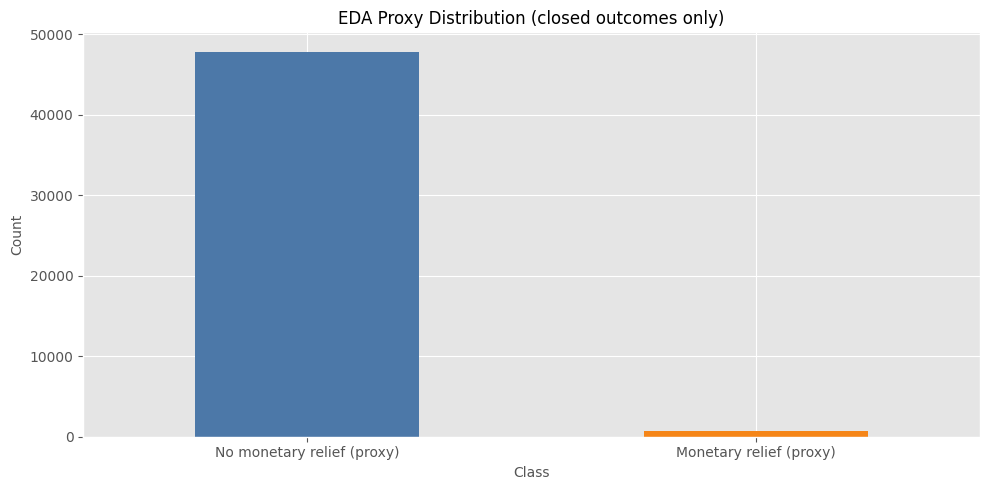

EDA proxy percentages (%), eligible rows only:
eda_monetary_proxy
0    98.61
1     1.39
Name: count, dtype: float64
Excluded ambiguous/unresolved rows: 1,501

Proxy rule: class 1 only for exact response "Closed with monetary relief".
Note: final modeling target is defined in 02_preprocessing.ipynb.


In [36]:
# EDA-only view: monetary-relief proxy distribution
if eda_base is not None:
    proxy_counts = eda_base['eda_monetary_proxy'].value_counts().sort_index()
    label_map = {0: 'No monetary relief (proxy)', 1: 'Monetary relief (proxy)'}
    plot_labels = [label_map.get(i, str(i)) for i in proxy_counts.index]

    ax = proxy_counts.plot(kind='bar', color=['#4C78A8', '#F58518'])
    ax.set_title('EDA Proxy Distribution (closed outcomes only)')
    ax.set_xlabel('Class')
    ax.set_ylabel('Count')
    ax.set_xticklabels(plot_labels, rotation=0)
    plt.tight_layout()
    plt.show()

    print('EDA proxy percentages (%), eligible rows only:')
    print((proxy_counts / proxy_counts.sum() * 100).round(2))
    print(f'Excluded ambiguous/unresolved rows: {(~eligible_mask).sum():,}')
    print('\nProxy rule: class 1 only for exact response "Closed with monetary relief".')
    print('Note: final modeling target is defined in 02_preprocessing.ipynb.')
else:
    print('EDA base not available. Check response column and proxy construction steps above.')


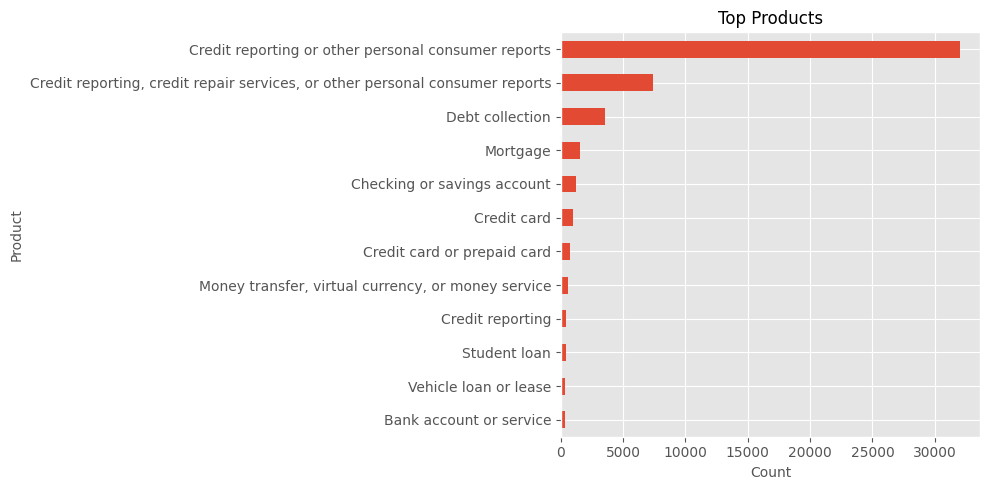

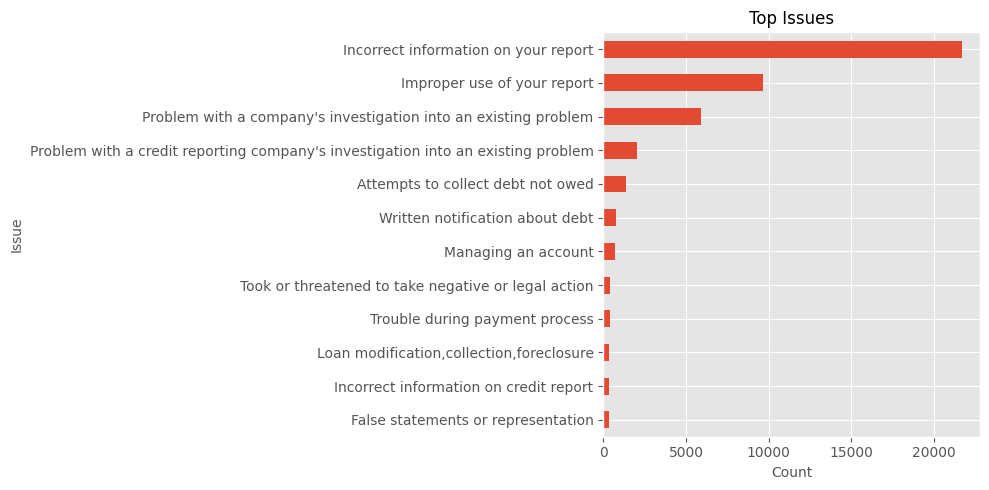

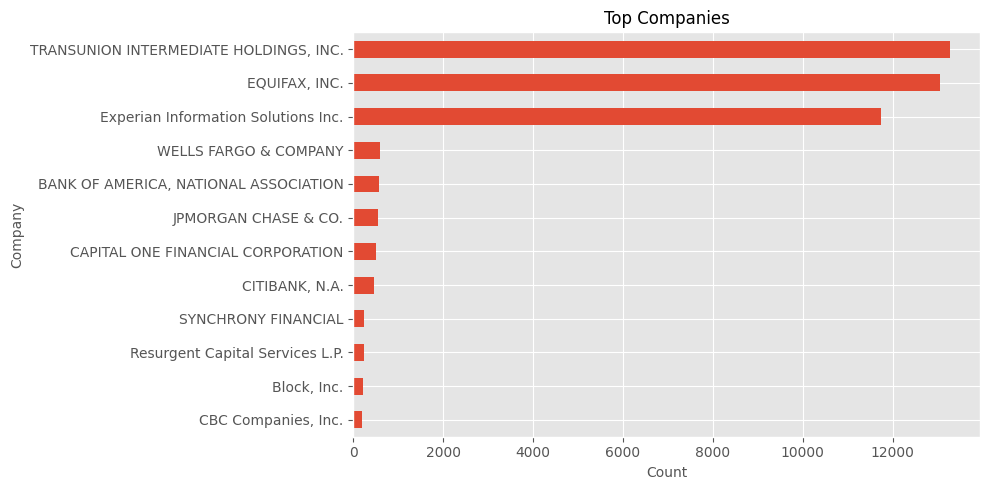

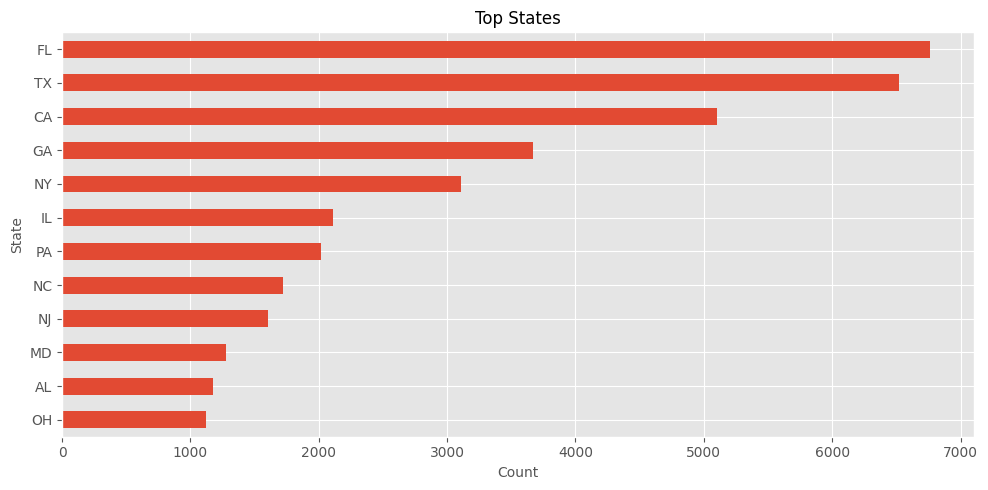

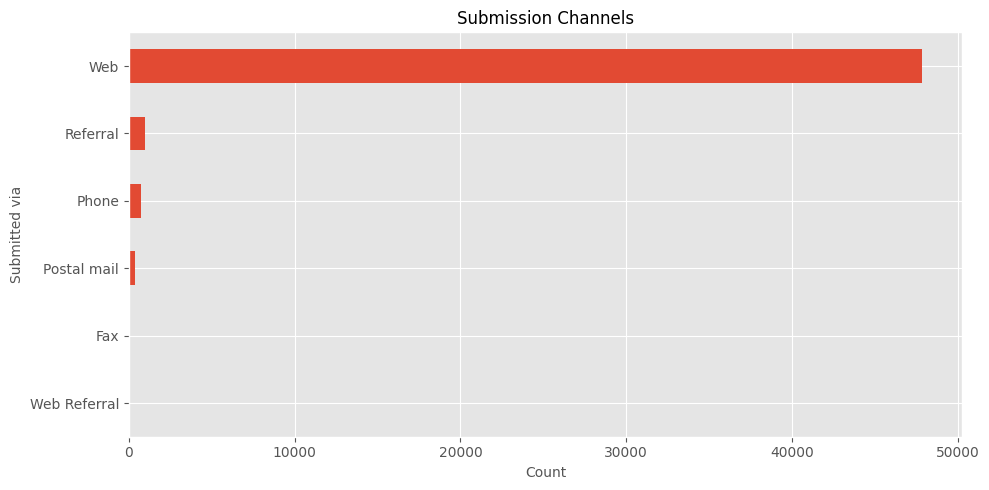

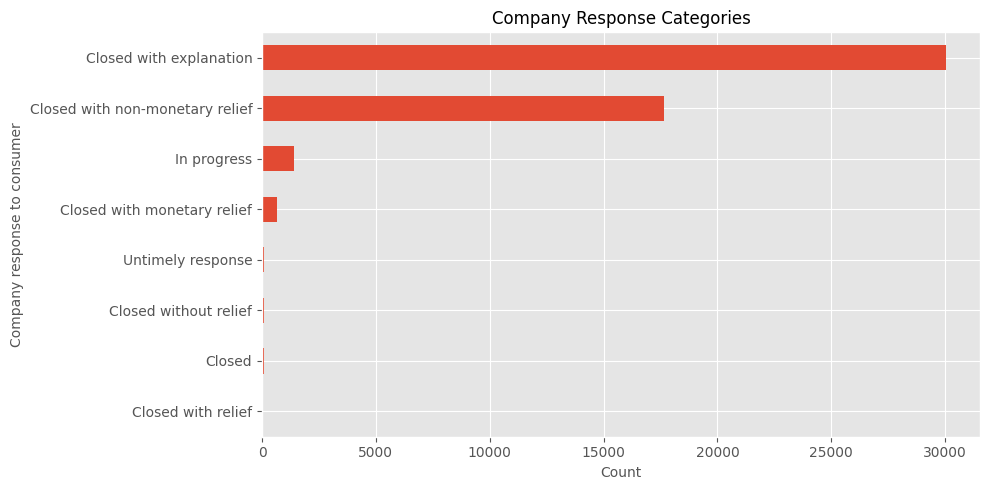

In [37]:
# Core categorical distributions
plot_top_counts(df, 'Product', top_n=12, title='Top Products')
plot_top_counts(df, 'Issue', top_n=12, title='Top Issues')
plot_top_counts(df, 'Company', top_n=12, title='Top Companies')
plot_top_counts(df, 'State', top_n=12, title='Top States')

# Submission channel and company response patterns (if present)
plot_top_counts(df, 'Submitted via', top_n=10, title='Submission Channels')
plot_top_counts(df, 'Company response to consumer', top_n=10, title='Company Response Categories')

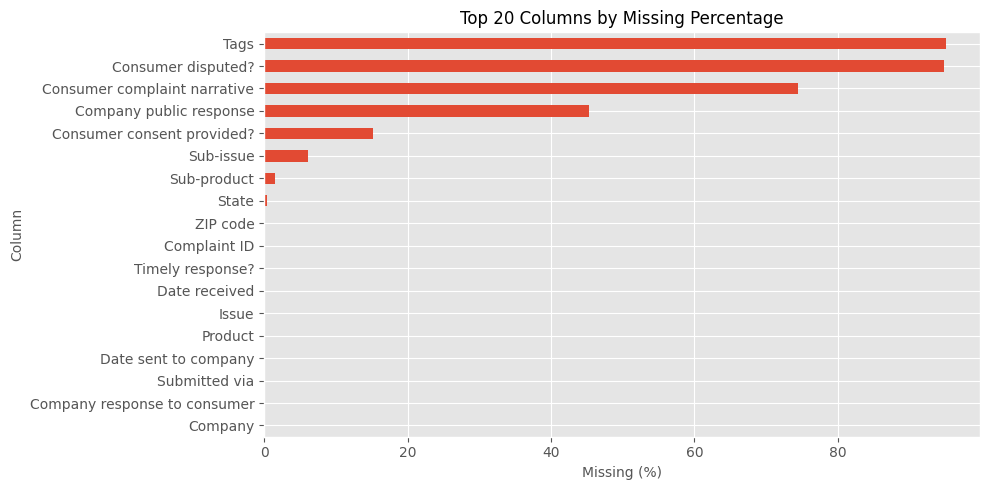

In [38]:
# Missingness profile for top columns by missing percentage
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
top_missing = missing_pct.head(20)

ax = top_missing.sort_values().plot(kind='barh')
ax.set_title('Top 20 Columns by Missing Percentage')
ax.set_xlabel('Missing (%)')
ax.set_ylabel('Column')
plt.tight_layout()
plt.show()

## 5. Extended Diagnostics

These diagnostics expand into category risk patterns, temporal stability, narrative signal checks, and class-conditional missingness.


,column,category,count,positive_rate,positive_rate_pct
14,Issue,Fees or interest,148,0.391892,39.19
15,Issue,Problem with a purchase shown on your statement,343,0.233236,23.32
0,Product,Bank account or service,295,0.223729,22.37
16,Issue,Problem when making payments,104,0.211538,21.15
1,Product,Credit card or prepaid card,722,0.178670,17.87
17,Issue,Problem caused by your funds being low,100,0.170000,17.00
18,Issue,Problem with a lender or other company chargin...,119,0.159664,15.97
19,Issue,Managing an account,716,0.153631,15.36
2,Product,Checking or savings account,1173,0.148338,14.83
20,Issue,Closing an account,135,0.148148,14.81


Saved category risk summary to ../reports/eda_category_risk_summary.csv


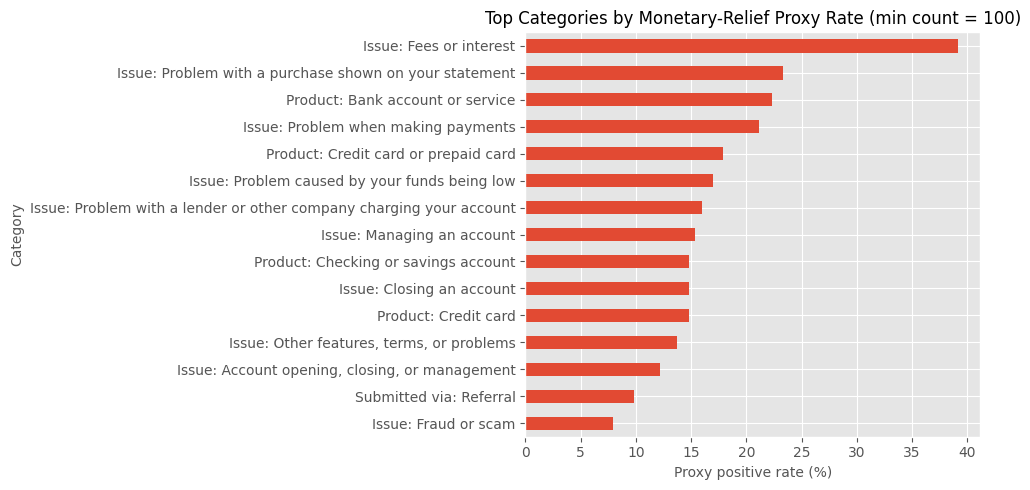

In [39]:
# Positive-rate diagnostics by category (with minimum support)
if eda_base is not None:
    min_count = 100
    category_cols = ['Product', 'Issue', 'Submitted via', 'State']
    frames = []

    for col in category_cols:
        if col not in eda_base.columns:
            continue
        grp = (
            eda_base.groupby(col, dropna=False)['eda_monetary_proxy']
            .agg(count='size', positive_rate='mean')
            .reset_index()
        )
        grp = grp[grp['count'] >= min_count].copy()
        grp['column'] = col
        grp = grp.sort_values(['positive_rate', 'count'], ascending=[False, False])
        frames.append(grp[['column', col, 'count', 'positive_rate']].rename(columns={col: 'category'}))

    if frames:
        category_risk = pd.concat(frames, ignore_index=True)
        category_risk['positive_rate_pct'] = (category_risk['positive_rate'] * 100).round(2)
        display(category_risk.sort_values(['positive_rate', 'count'], ascending=[False, False]).head(25))

        out_path = Path('../reports/eda_category_risk_summary.csv')
        category_risk.to_csv(out_path, index=False)
        print(f'Saved category risk summary to {out_path}')

        top_plot = category_risk.sort_values('positive_rate', ascending=False).head(15).copy()
        top_plot = top_plot.iloc[::-1]
        labels = top_plot['column'] + ': ' + top_plot['category'].astype(str)
        ax = top_plot['positive_rate_pct'].plot(kind='barh')
        ax.set_title('Top Categories by Monetary-Relief Proxy Rate (min count = 100)')
        ax.set_xlabel('Proxy positive rate (%)')
        ax.set_ylabel('Category')
        ax.set_yticks(range(len(labels)))
        ax.set_yticklabels(labels)
        plt.tight_layout()
        plt.show()
    else:
        print('No category columns available for risk summary.')

,year_month_label,complaint_count,positive_rate_pct
161,2025-05,1411,0.496
162,2025-06,1389,0.576
163,2025-07,1583,0.569
164,2025-08,1661,0.542
165,2025-09,1743,0.344
166,2025-10,1875,0.427
167,2025-11,1695,0.354
168,2025-12,1762,0.795
169,2026-01,1827,0.328
170,2026-02,1593,0.565


Saved temporal summary to ../reports/eda_temporal_proxy_summary.csv


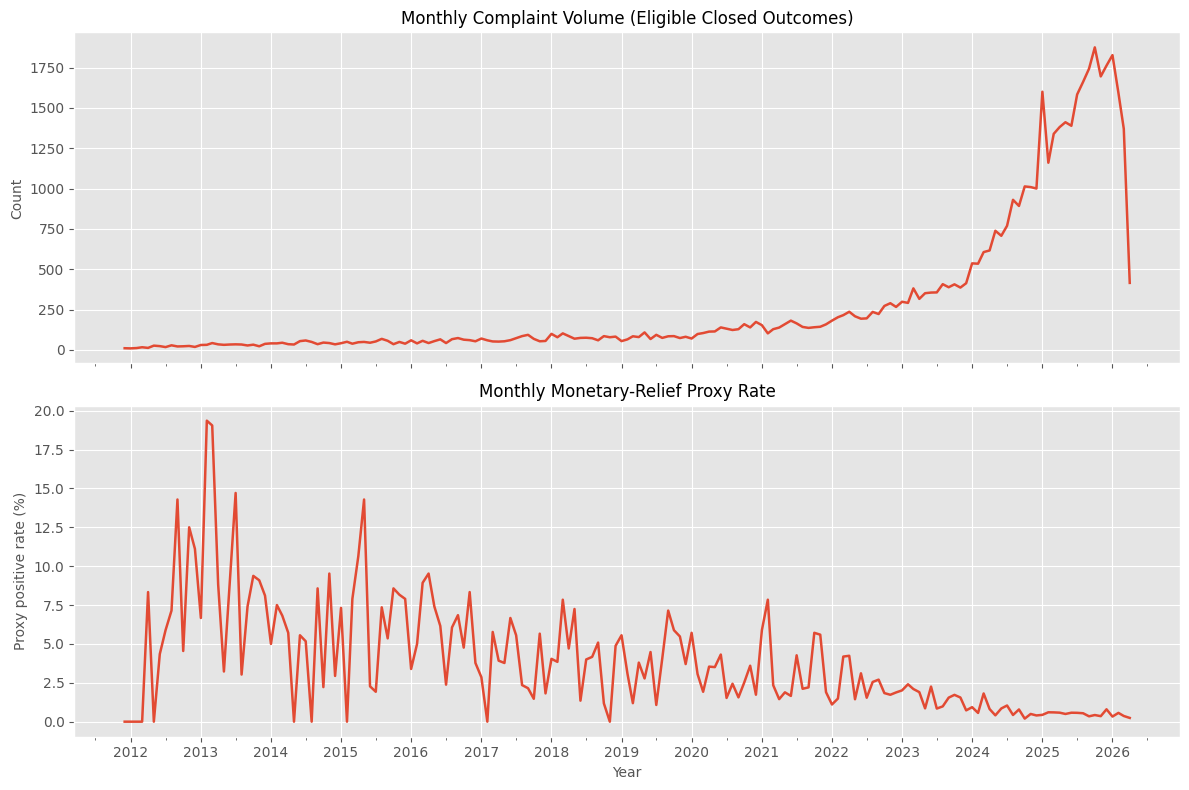

In [40]:
# Temporal stability check: volume and proxy rate over time
if eda_base is not None and 'Date received' in eda_base.columns:
    import matplotlib.dates as mdates

    monthly = eda_base.copy()
    monthly['Date received'] = pd.to_datetime(monthly['Date received'], errors='coerce')
    monthly = monthly.dropna(subset=['Date received'])
    monthly['year_month'] = monthly['Date received'].dt.to_period('M').dt.to_timestamp()

    monthly_summary = (
        monthly.groupby('year_month')['eda_monetary_proxy']
        .agg(complaint_count='size', positive_rate='mean')
        .reset_index()
        .sort_values('year_month')
    )
    monthly_summary['positive_rate_pct'] = (monthly_summary['positive_rate'] * 100).round(3)
    monthly_summary['year_month_label'] = monthly_summary['year_month'].dt.strftime('%Y-%m')
    display(monthly_summary[['year_month_label', 'complaint_count', 'positive_rate_pct']].tail(12))

    out_path = Path('../reports/eda_temporal_proxy_summary.csv')
    monthly_summary.to_csv(out_path, index=False)
    print(f'Saved temporal summary to {out_path}')

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    axes[0].plot(monthly_summary['year_month'], monthly_summary['complaint_count'], color='#E24A33', linewidth=1.8)
    axes[0].set_title('Monthly Complaint Volume (Eligible Closed Outcomes)')
    axes[0].set_ylabel('Count')

    axes[1].plot(monthly_summary['year_month'], monthly_summary['positive_rate_pct'], color='#E24A33', linewidth=1.8)
    axes[1].set_title('Monthly Monetary-Relief Proxy Rate')
    axes[1].set_ylabel('Proxy positive rate (%)')
    axes[1].set_xlabel('Year')

    # Reduce clutter: show one major tick per year and lightly mark half-years.
    axes[1].xaxis.set_major_locator(mdates.YearLocator(base=1))
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[1].xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[1, 7]))
    axes[1].tick_params(axis='x', rotation=0)

    plt.tight_layout()
    plt.show()
else:
    print('Date received column not available for temporal analysis.')

,eda_monetary_proxy,count,has_narrative_rate,narrative_length_median,narrative_length_mean,has_narrative_rate_pct
0,0,47827,0.259414,0.0,261.590043,25.94
1,1,672,0.471726,0.0,641.172619,47.17


Saved narrative summary to ../reports/eda_narrative_proxy_summary.csv


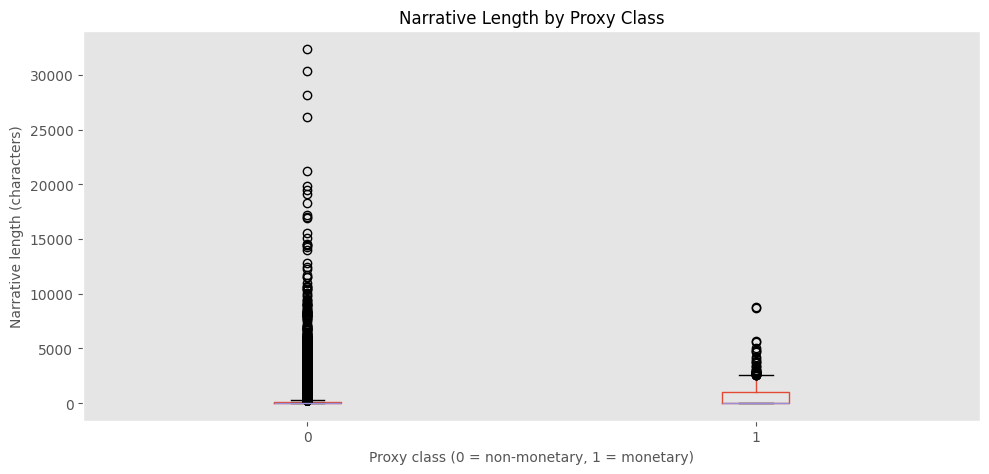

In [41]:
# Narrative diagnostics by proxy class
if eda_base is not None and 'Consumer complaint narrative' in eda_base.columns:
    narrative_df = eda_base[['Consumer complaint narrative', 'eda_monetary_proxy']].copy()
    narrative_df['has_narrative'] = narrative_df['Consumer complaint narrative'].notna().astype(int)
    narrative_df['narrative_length'] = (
        narrative_df['Consumer complaint narrative']
        .fillna('')
        .astype(str)
        .str.len()
    )

    narrative_summary = (
        narrative_df.groupby('eda_monetary_proxy')
        .agg(
            count=('eda_monetary_proxy', 'size'),
            has_narrative_rate=('has_narrative', 'mean'),
            narrative_length_median=('narrative_length', 'median'),
            narrative_length_mean=('narrative_length', 'mean')
        )
        .reset_index()
    )
    narrative_summary['has_narrative_rate_pct'] = (narrative_summary['has_narrative_rate'] * 100).round(2)
    display(narrative_summary)

    out_path = Path('../reports/eda_narrative_proxy_summary.csv')
    narrative_summary.to_csv(out_path, index=False)
    print(f'Saved narrative summary to {out_path}')

    ax = narrative_df.boxplot(column='narrative_length', by='eda_monetary_proxy', grid=False)
    plt.title('Narrative Length by Proxy Class')
    plt.suptitle('')
    ax.set_xlabel('Proxy class (0 = non-monetary, 1 = monetary)')
    ax.set_ylabel('Narrative length (characters)')
    plt.tight_layout()
    plt.show()
else:
    print('Consumer complaint narrative column not available for narrative diagnostics.')

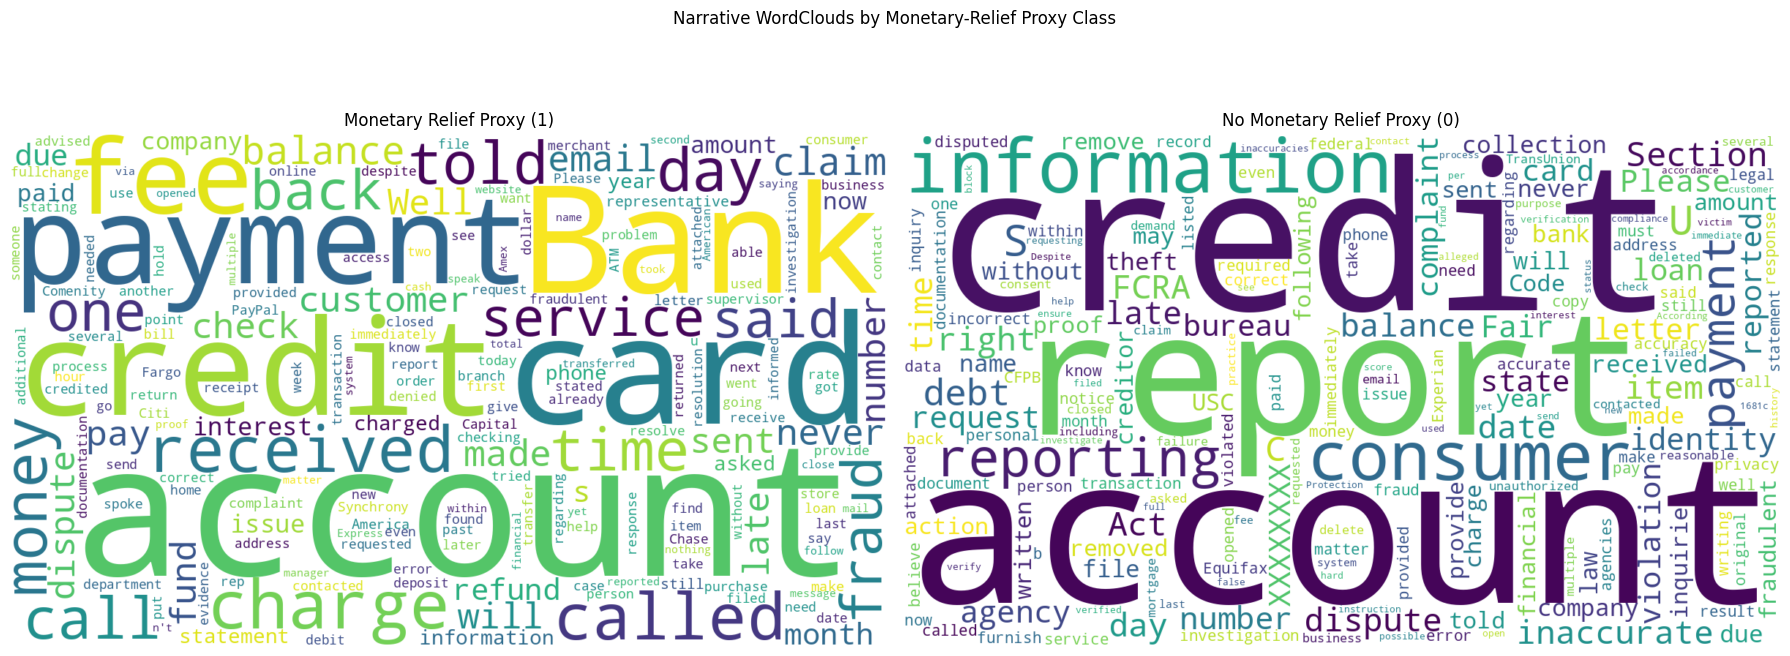

In [42]:
# Side-by-side word clouds for monetary vs non-monetary proxy classes (EDA visualization)
if eda_base is not None and 'Consumer complaint narrative' in eda_base.columns:
    try:
        from wordcloud import WordCloud, STOPWORDS

        wc_df = eda_base[['Consumer complaint narrative', 'eda_monetary_proxy']].copy()
        wc_df = wc_df.dropna(subset=['Consumer complaint narrative'])
        wc_df['Consumer complaint narrative'] = (
            wc_df['Consumer complaint narrative'].astype(str).str.strip()
        )
        wc_df = wc_df[wc_df['Consumer complaint narrative'] != '']

        def build_wordcloud(text_series):
            text_blob = ' '.join(text_series.tolist())
            if not text_blob.strip():
                return None
            custom_stopwords = set(STOPWORDS) | {'xxxx', 'xx', 'na', 'n/a'}
            return WordCloud(
                width=1200,
                height=700,
                background_color='white',
                colormap='viridis',
                max_words=200,
                stopwords=custom_stopwords,
                collocations=False,
            ).generate(text_blob)

        monetary_text = wc_df.loc[wc_df['eda_monetary_proxy'] == 1, 'Consumer complaint narrative']
        non_monetary_text = wc_df.loc[wc_df['eda_monetary_proxy'] == 0, 'Consumer complaint narrative']

        wc_monetary = build_wordcloud(monetary_text)
        wc_non_monetary = build_wordcloud(non_monetary_text)

        fig, axes = plt.subplots(1, 2, figsize=(18, 7))
        clouds = [
            (wc_monetary, 'Monetary Relief Proxy (1)'),
            (wc_non_monetary, 'No Monetary Relief Proxy (0)'),
        ]

        for ax, (wc_obj, title) in zip(axes, clouds):
            if wc_obj is not None:
                ax.imshow(wc_obj, interpolation='bilinear')
            else:
                ax.text(0.5, 0.5, 'No narrative text available', ha='center', va='center')
            ax.set_title(title)
            ax.axis('off')

        plt.suptitle('Narrative WordClouds by Monetary-Relief Proxy Class', y=1.02)
        plt.tight_layout()
        plt.show()

    except ModuleNotFoundError:
        print("wordcloud is not installed. Run: pip install wordcloud")
else:
    print('Consumer complaint narrative column not available for wordcloud diagnostics.')


In [43]:
# Missingness by proxy class and variable-prep summary for report
if eda_base is not None:
    top_missing_cols = (eda_base.isna().mean() * 100).sort_values(ascending=False).head(15).index.tolist()

    miss_rows = []
    for col in top_missing_cols:
        stats = (
            eda_base.groupby('eda_monetary_proxy')[col]
            .apply(lambda s: s.isna().mean() * 100)
            .to_dict()
        )
        miss_rows.append({
            'variable': col,
            'missing_pct_proxy_0': round(stats.get(0, 0.0), 3),
            'missing_pct_proxy_1': round(stats.get(1, 0.0), 3),
            'gap_pct_points': round(abs(stats.get(0, 0.0) - stats.get(1, 0.0)), 3),
        })

    missing_by_proxy = pd.DataFrame(miss_rows).sort_values('gap_pct_points', ascending=False)
    display(missing_by_proxy.head(15))

    out_path_1 = Path('../reports/eda_missingness_by_proxy.csv')
    missing_by_proxy.to_csv(out_path_1, index=False)
    print(f'Saved missingness-by-proxy summary to {out_path_1}')

    prep_rows = []
    for col in eda_base.columns:
        if col == 'eda_monetary_proxy':
            continue
        missing_pct = round(eda_base[col].isna().mean() * 100, 3)
        dtype = str(eda_base[col].dtype)
        if col == 'Consumer complaint narrative':
            transform = 'text cleaning + vectorization in preprocessing/modeling pipeline'
            relevance = 'core text signal for monetary-relief prediction'
        elif col in ['Product', 'Issue', 'State', 'Submitted via']:
            transform = 'categorical encoding (one-hot in preprocessing)'
            relevance = 'structured complaint context feature'
        elif col in ['Date received', 'Date sent to company']:
            transform = 'datetime parsing + temporal feature extraction'
            relevance = 'time effects and process timing signal'
        elif col == 'Company response to consumer':
            transform = 'used for label derivation only, excluded from predictors'
            relevance = 'target construction only (leakage control)'
        else:
            transform = 'retain or transform based on type in preprocessing'
            relevance = 'candidate supporting feature'
        prep_rows.append({
            'variable': col,
            'dtype': dtype,
            'missing_pct': missing_pct,
            'candidate_transformation': transform,
            'relevance_note': relevance,
        })

    prep_summary = pd.DataFrame(prep_rows).sort_values('missing_pct', ascending=False)
    out_path_2 = Path('../reports/eda_variable_preparation_summary.csv')
    prep_summary.to_csv(out_path_2, index=False)
    print(f'Saved variable-preparation summary to {out_path_2}')
    display(prep_summary.head(20))

,variable,missing_pct_proxy_0,missing_pct_proxy_1,gap_pct_points
5,Sub-issue,5.972,31.548,25.576
2,Consumer complaint narrative,74.059,52.827,21.231
4,Consumer consent provided?,12.478,32.292,19.813
1,Consumer disputed?,94.925,75.595,19.330
0,Tags,95.145,82.292,12.853
6,Sub-product,1.453,8.482,7.029
3,Company public response,43.574,50.446,6.873
7,State,0.389,1.637,1.248
8,ZIP code,0.192,1.042,0.849
9,Product,0.000,0.000,0.000


Saved missingness-by-proxy summary to ../reports/eda_missingness_by_proxy.csv
Saved variable-preparation summary to ../reports/eda_variable_preparation_summary.csv


,variable,dtype,missing_pct,candidate_transformation,relevance_note
10,Tags,str,94.967,retain or transform based on type in preproces...,candidate supporting feature
16,Consumer disputed?,str,94.658,retain or transform based on type in preproces...,candidate supporting feature
5,Consumer complaint narrative,str,73.764,text cleaning + vectorization in preprocessing...,core text signal for monetary-relief prediction
6,Company public response,str,43.669,retain or transform based on type in preproces...,candidate supporting feature
11,Consumer consent provided?,str,12.753,retain or transform based on type in preproces...,candidate supporting feature
4,Sub-issue,str,6.326,retain or transform based on type in preproces...,candidate supporting feature
2,Sub-product,str,1.551,retain or transform based on type in preproces...,candidate supporting feature
8,State,str,0.406,categorical encoding (one-hot in preprocessing),structured complaint context feature
9,ZIP code,str,0.204,retain or transform based on type in preproces...,candidate supporting feature
0,Date received,str,0.000,datetime parsing + temporal feature extraction,time effects and process timing signal


## 6. Artifact Exports

Consolidate generated tables/figures and verify report-ready outputs.


In [44]:
# Quick check of EDA artifacts generated in reports/
eda_outputs = [
    '../reports/eda_label_policy_summary.csv',
    '../reports/eda_category_risk_summary.csv',
    '../reports/eda_temporal_proxy_summary.csv',
    '../reports/eda_narrative_proxy_summary.csv',
    '../reports/eda_missingness_by_proxy.csv',
    '../reports/eda_variable_preparation_summary.csv',
]

output_status = pd.DataFrame({
    'file': eda_outputs,
    'exists': [Path(p).exists() for p in eda_outputs],
})
display(output_status)
print(f"Artifacts present: {output_status['exists'].sum()} / {len(output_status)}")

,file,exists
0,../reports/eda_label_policy_summary.csv,True
1,../reports/eda_category_risk_summary.csv,True
2,../reports/eda_temporal_proxy_summary.csv,True
3,../reports/eda_narrative_proxy_summary.csv,True
4,../reports/eda_missingness_by_proxy.csv,True
5,../reports/eda_variable_preparation_summary.csv,True


Artifacts present: 6 / 6


In [45]:
reports_dir = Path('../reports')
assets_dir = Path('../reports/final_report/assets')
assets_dir.mkdir(parents=True, exist_ok=True)

# Figure 1: Label policy distribution from EDA artifacts
policy_path = reports_dir / 'eda_label_policy_summary.csv'
policy_df = pd.read_csv(policy_path)

policy_agg = (
    policy_df.groupby('policy_group', as_index=False)['count']
    .sum()
    .sort_values('count', ascending=False)
)

label_map = {
    'negative_non_monetary': 'Negative\n(non-monetary closed)',
    'positive_monetary': 'Positive\n(monetary relief)',
    'excluded_ambiguous_or_unresolved': 'Excluded\n(ambiguous/unresolved)',
}
policy_agg['policy_label'] = policy_agg['policy_group'].map(label_map).fillna(policy_agg['policy_group'])

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#4C78A8', '#F58518', '#9C755F']
ax.bar(policy_agg['policy_label'], policy_agg['count'], color=colors[:len(policy_agg)])
ax.set_title('Response Policy Group Distribution in Working Sample')
ax.set_ylabel('Count')
ax.set_xlabel('Policy group')
ax.tick_params(axis='x', rotation=0)
for i, v in enumerate(policy_agg['count']):
    ax.text(i, v, f'{int(v):,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
fig.savefig(assets_dir / 'data_prep_label_policy.png', dpi=300, bbox_inches='tight')
plt.close(fig)

# Figure 2: Top missingness profile from EDA artifacts
missing_path = reports_dir / 'eda_variable_preparation_summary.csv'
missing_df = pd.read_csv(missing_path)
missing_top = missing_df.sort_values('missing_pct', ascending=False).head(10).copy()
missing_top = missing_top.sort_values('missing_pct', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(missing_top['variable'], missing_top['missing_pct'], color='#72B7B2')
ax.set_title('Top 10 Variables by Missingness (Working Sample)')
ax.set_xlabel('Missing (%)')
ax.set_ylabel('Variable')
for y, v in enumerate(missing_top['missing_pct']):
    ax.text(v + 0.5, y, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout()
fig.savefig(assets_dir / 'data_prep_missingness_top10.png', dpi=300, bbox_inches='tight')
plt.close(fig)

# Figure 3: Monthly complaint volume from temporal summary
temporal_path = reports_dir / 'eda_temporal_proxy_summary.csv'
temporal_df = pd.read_csv(temporal_path)
temporal_df['year_month'] = pd.to_datetime(temporal_df['year_month'])
temporal_df = temporal_df.sort_values('year_month')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(temporal_df['year_month'], temporal_df['complaint_count'], color='#E45756', linewidth=1.8)
ax.set_title('Monthly Complaint Volume (Eligible Closed Outcomes)')
ax.set_xlabel('Year')
ax.set_ylabel('Complaint count')
plt.tight_layout()
fig.savefig(assets_dir / 'data_prep_monthly_volume.png', dpi=300, bbox_inches='tight')
plt.close(fig)

print('Exported Data Preparation figures:')
for name in [
    'data_prep_label_policy.png',
    'data_prep_missingness_top10.png',
    'data_prep_monthly_volume.png',
]:
    print(f'- {assets_dir / name}')


Exported Data Preparation figures:
- ../reports/final_report/assets/data_prep_label_policy.png
- ../reports/final_report/assets/data_prep_missingness_top10.png
- ../reports/final_report/assets/data_prep_monthly_volume.png


## 7. Notes and Handoff

This notebook analyzes a sampled dataset for speed and memory safety. Rates and distributions can differ from the full raw dataset.

The monetary-relief variable shown here is an exploratory proxy. The final supervised label used for modeling is created in preprocessing using shared policy logic.

Temporal and category views are descriptive and may be affected by sparse groups or period-level volatility. Notebook 2 formalizes transformations and leakage controls, and Notebook 3 performs threshold-aware model evaluation.
